In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

# Set visual style
sns.set_theme(style="whitegrid")
print("Libraries loaded!")

Libraries loaded!


In [2]:
# 1. Load income data
income_df = pd.read_csv(r'data\ACSST5Y2024.S1901-Data.csv', skiprows=[1])

# 2.Cleanup
income_cols = ['S1901_C01_012E', 'S1901_C02_012E', 'S1901_C03_012E']
for col in income_cols:
    # Remove commas/plus signs and force to numeric
    income_df[col] = income_df[col].astype(str).str.replace(',', '').str.replace('+', '')
    income_df[col] = pd.to_numeric(income_df[col], errors='coerce')

# 3. Subset and Rename
income_df = income_df[['GEO_ID', 'S1901_C01_012E']].copy()
income_df.columns = ['geo_id', 'median_income']

# 4. Extract Zip Code and final drop of NaNs
income_df['zip_code'] = income_df['geo_id'].str.split('US').str[-1]
income_df = income_df.dropna(subset=['median_income'])

print(f"Loaded income data for {len(income_df)} Zip Codes.")
income_df.head()

Loaded income data for 1637 Zip Codes.


,geo_id,median_income,zip_code
0,860Z200US06390,98125.0,06390
1,860Z200US10001,129852.0,10001
2,860Z200US10002,48386.0,10002
3,860Z200US10003,154262.0,10003
4,860Z200US10004,250000.0,10004


In [3]:
# Load the tree data
trees_df = pd.read_csv('data/2015_Street_Tree_Census_-_Tree_Data_20260315.csv')

# Cleanup

# 1. Filter to only 'Alive' trees (we can't measure the health of a stump)
trees_df = trees_df[trees_df['status'] == 'Alive'].copy()

# 2. Keep only the relevant columns
trees_df = trees_df[['tree_id', 'health', 'postcode', 'spc_common', 'borough']]

# 3. Ensure Zip Code (postcode) is a string to match the income data
trees_df['postcode'] = trees_df['postcode'].astype(str)

health_map = {'Good': 3, 'Fair': 2, 'Poor': 1}
trees_df['health_numeric'] = trees_df['health'].map(health_map)

# Filter for alive trees ONLY (handles non-living trees)
if 'status' in trees_df.columns:
    trees_alive = trees_df[trees_df['status'] == 'Alive'].copy()
else:
    trees_alive = trees_df.copy()

trees_alive['postcode'] = trees_alive['postcode'].astype(str)

print(f"Loaded {len(trees_df)} living trees.")
trees_df.head()

Loaded 652173 living trees.


,tree_id,health,postcode,spc_common,borough,health_numeric
0,180683,Fair,11375,red maple,Queens,2.0
1,200540,Fair,11357,pin oak,Queens,2.0
2,204026,Good,11211,honeylocust,Brooklyn,3.0
3,204337,Good,11211,honeylocust,Brooklyn,3.0
4,189565,Good,11215,American linden,Brooklyn,3.0


In [4]:
# --- 3. TREE DATA AGGREGATION ---
# We use .agg() and then IMMEDIATELY rename the columns to match your later code
tree_stats = trees_alive.groupby('postcode').agg({
    'tree_id': 'count',
    'health_numeric': 'mean',
    'borough': 'first'  
}).reset_index()

tree_stats.columns = ['zip_code', 'tree_count', 'health_numeric', 'borough']

# Calculate % Good Health safely
health_counts = trees_alive.groupby(['postcode', 'health']).size().unstack(fill_value=0)
if 'Good' not in health_counts.columns: health_counts['Good'] = 0
health_counts['total'] = health_counts.sum(axis=1)
health_counts['percent_good'] = (health_counts['Good'] / health_counts['total']) * 100

# Merge the % Good metric back into tree_stats
tree_stats = tree_stats.merge(health_counts[['percent_good']], left_on='zip_code', right_index=True)

# --- 4. MASTER MERGE ---
final_df = pd.merge(tree_stats, income_df, on='zip_code').dropna(subset=['median_income', 'percent_good'])

print(f"Harmonization Complete: {len(final_df)} Zip Codes successfully linked.")
final_df.head()

Harmonization Complete: 181 Zip Codes successfully linked.


,zip_code,tree_count,health_numeric,borough,percent_good,geo_id,median_income
0,10001,850,2.809412,Manhattan,84.588235,860Z200US10001,129852.0
1,10002,2158,2.714087,Manhattan,76.737720,860Z200US10002,48386.0
2,10003,1943,2.709213,Manhattan,76.170870,860Z200US10003,154262.0
3,10004,117,2.803419,Manhattan,82.905983,860Z200US10004,250000.0
4,10005,130,2.346154,Manhattan,45.384615,860Z200US10005,190233.0


In [5]:
# Z-Score filter for outliers

# Remove Zip Codes with very few trees (e.g., less than 50)
filtered_df = final_df[final_df['tree_count'] > 50].copy()

# Filter out extreme income outliers (more than 3 standard deviations away)
z_scores = np.abs(stats.zscore(filtered_df['median_income']))
clean_df = filtered_df[z_scores < 3]

print(f"Removed {len(final_df) - len(clean_df)} outlier Zip Codes.")

Removed 7 outlier Zip Codes.


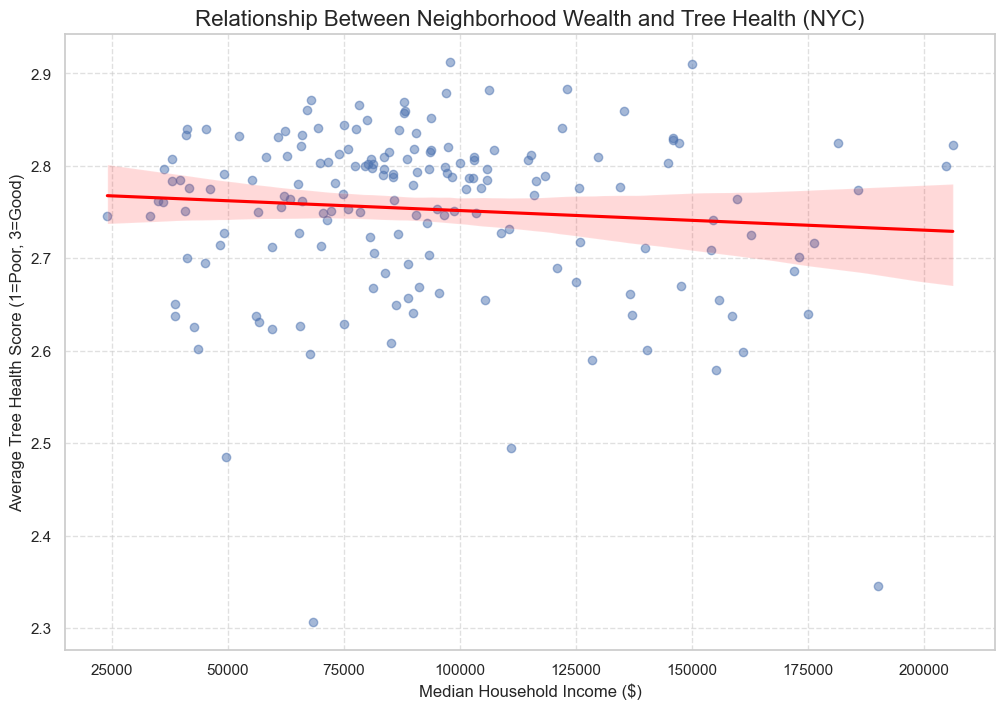

In [6]:

# Create the scatter plot with a regression line
plt.figure(figsize=(12, 8))

# Use 'health_numeric' 
# Also using clean_df here makes the graph much more readable!
sns.regplot(data=clean_df, x='median_income', y='health_numeric', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.title('Relationship Between Neighborhood Wealth and Tree Health (NYC)', fontsize=16)
plt.xlabel('Median Household Income ($)', fontsize=12)
plt.ylabel('Average Tree Health Score (1=Poor, 3=Good)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [7]:
# Calculate the correlation matrix using the cleaned data
# We use 'health_numeric' because that is the name defined in our harmonization block
correlation = clean_df['median_income'].corr(clean_df['health_numeric'])

print(f"The Correlation between Income and Tree Health (Cleaned) is: {correlation:.2f}")

if correlation > 0.3:
    print("Result: There is a moderate to strong positive relationship!")
elif correlation > 0.1:
    print("Result: There is a weak positive relationship.")
elif correlation > -0.1:
    print("Result: There is virtually no linear relationship across the whole city.")
else:
    print("Result: There is a negative relationship.")

# Double check: Also look at the % Good Health correlation
corr_percent = clean_df['median_income'].corr(clean_df['percent_good'])
print(f"The Correlation for % Good Health is: {corr_percent:.2f}")

The Correlation between Income and Tree Health (Cleaned) is: -0.09
Result: There is virtually no linear relationship across the whole city.
The Correlation for % Good Health is: -0.08


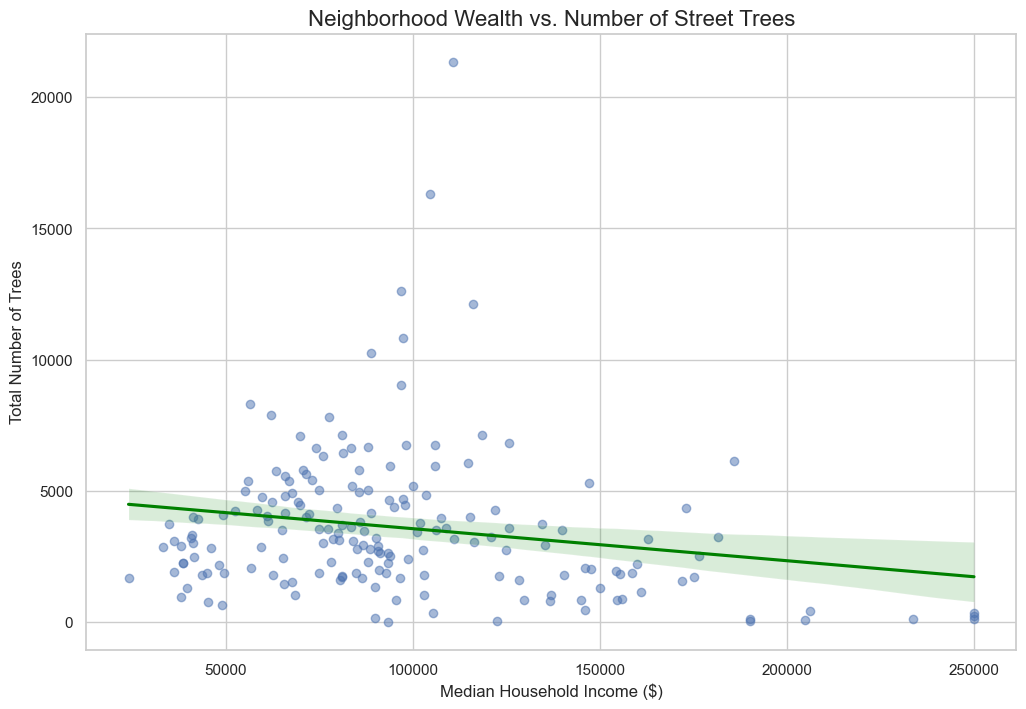

In [8]:
# Scatter plot for Income vs. Total Tree Count
plt.figure(figsize=(12, 8))
sns.regplot(data=final_df, x='median_income', y='tree_count', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'green'})

plt.title('Neighborhood Wealth vs. Number of Street Trees', fontsize=16)
plt.xlabel('Median Household Income ($)', fontsize=12)
plt.ylabel('Total Number of Trees', fontsize=12)

plt.show()

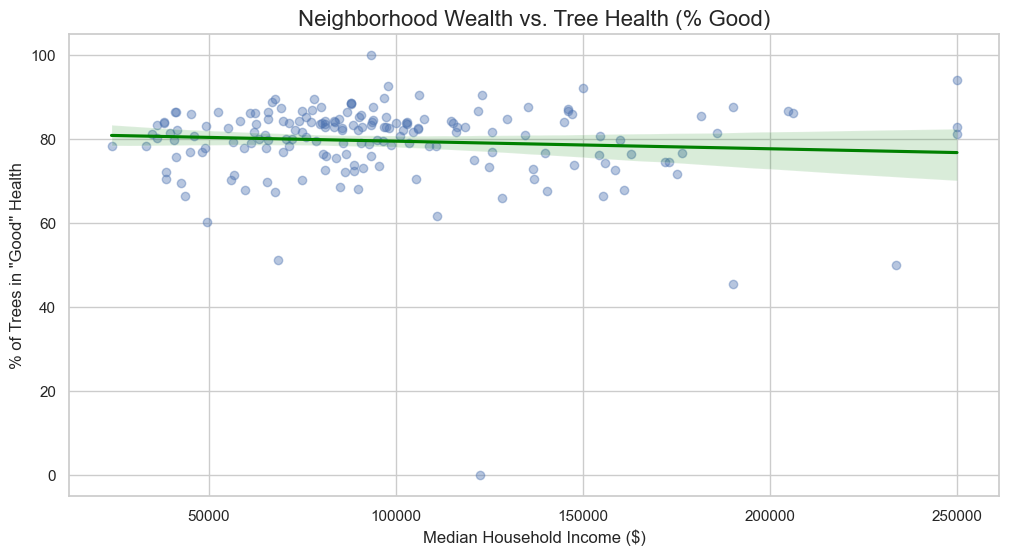

In [9]:
# 1. Prepare health counts safely
# If 'status' is missing, it means we likely already filtered for 'Alive' trees earlier
if 'status' in trees_df.columns:
    health_counts_df = trees_df[trees_df['status'] == 'Alive'].copy()
else:
    health_counts_df = trees_df.copy()

# Ensure postcode is a string to match the census data zip_code
health_counts_df['postcode'] = health_counts_df['postcode'].astype(str)

# 2. Pivot the data to get Good/Fair/Poor counts per Zip
health_pivot = health_counts_df.groupby(['postcode', 'health']).size().unstack(fill_value=0)

# 3. Calculate the percentage
# We check if 'Good' exists in case a zip code has only 'Fair' or 'Poor' trees
if 'Good' in health_pivot.columns:
    health_pivot['total'] = health_pivot.sum(axis=1)
    health_pivot['percent_good'] = (health_pivot['Good'] / health_pivot['total']) * 100
else:
    health_pivot['percent_good'] = 0

# 4. MERGE: Add the new metric to final_df
# We drop the column first if it already exists to avoid '.x' or '.y' suffixes
if 'percent_good' in final_df.columns:
    final_df = final_df.drop(columns=['percent_good'])

final_df = final_df.merge(
    health_pivot[['percent_good']], 
    left_on='zip_code', 
    right_index=True, 
    how='left'
)

# 5. Plotting
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.regplot(data=final_df, x='median_income', y='percent_good', 
            scatter_kws={'alpha':0.4}, line_kws={'color':'green'})

plt.title('Neighborhood Wealth vs. Tree Health (% Good)', fontsize=16)
plt.xlabel('Median Household Income ($)', fontsize=12)
plt.ylabel('% of Trees in "Good" Health', fontsize=12)
plt.show()

In [10]:
# We haven't found a correlations so far...
# Analyzing the whole city at once mixes concrete jungles (Manhattan) with garden boroughs (Queens). 
# Lets try splitting the scatter plot by Borough.

# --- STEP 1: ADD BOROUGH INFO ---
# Create the lookup from the original trees_df 
zip_to_borough = trees_df.groupby('postcode')['borough'].first().reset_index()
zip_to_borough.columns = ['zip_code', 'borough']

# Merge it into final_df
if 'borough' not in final_df.columns:
    final_df = final_df.merge(zip_to_borough, on='zip_code', how='left')

# --- STEP 2: CREATE THE CLEAN VERSION ---
# We remove Zip Codes with < 20 trees and income outliers

# 1. Filter by tree count
clean_df = final_df[final_df['tree_count'] > 20].copy()

# 2. Filter by Income (removing top/bottom 1% or using Z-score)
z_scores = np.abs(stats.zscore(clean_df['median_income']))
clean_df = clean_df[z_scores < 3]

print(f"Cleaned data ready. Using {len(clean_df)} neighborhoods out of {len(final_df)}.")

# --- STEP 3: BOROUGH CORRELATION ---
print("\n--- Correlation by Borough (Wealth vs. % Good Health) ---")
for borough in clean_df['borough'].dropna().unique():
    subset = clean_df[clean_df['borough'] == borough]
    # We need at least a few data points to calculate correlation
    if len(subset) > 5:
        corr = subset['median_income'].corr(subset['percent_good'])
        print(f"{borough:15} | Correlation: {corr:+.2f} | Zip Codes: {len(subset)}")

# In the Bronx, we have a correlation of +0.46, which is statistically significant
# This suggests that in the Bronx, private investment or local stewardship could be related to socioeconomic status

Cleaned data ready. Using 176 neighborhoods out of 181.

--- Correlation by Borough (Wealth vs. % Good Health) ---
Manhattan       | Correlation: -0.01 | Zip Codes: 39
Staten Island   | Correlation: -0.08 | Zip Codes: 12
Bronx           | Correlation: +0.46 | Zip Codes: 25
Queens          | Correlation: +0.04 | Zip Codes: 62
Brooklyn        | Correlation: -0.05 | Zip Codes: 38


In [11]:
# This calculates the correlation for EACH borough separately
for borough in clean_df['borough'].unique():
    subset = clean_df[clean_df['borough'] == borough]
    corr = subset['median_income'].corr(subset['percent_good'])
    print(f"Correlation in {borough}: {corr:.2f}")

Correlation in Manhattan: -0.01
Correlation in Staten Island: -0.08
Correlation in Bronx: 0.46
Correlation in Queens: 0.04
Correlation in Brooklyn: -0.05


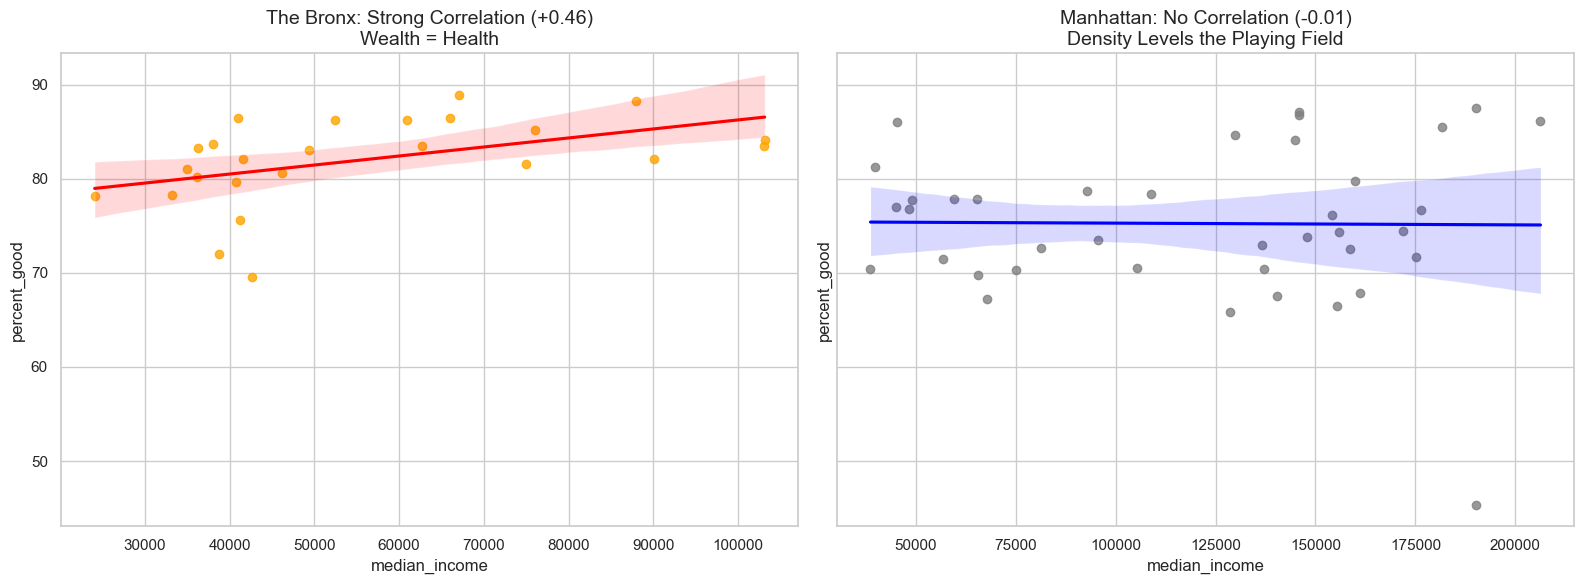

In [12]:
# Create a side-by-side comparison of the Bronx and Manhattan
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Plot 1: The Bronx (The Strong Link)
bronx_data = clean_df[clean_df['borough'] == 'Bronx']
sns.regplot(data=bronx_data, x='median_income', y='percent_good', 
            ax=ax1, color='orange', line_kws={'color':'red'})
ax1.set_title(f'The Bronx: Strong Correlation (+0.46)\nWealth = Health', fontsize=14)

# Plot 2: Manhattan (The Concrete Jungle)
manhattan_data = clean_df[clean_df['borough'] == 'Manhattan']
sns.regplot(data=manhattan_data, x='median_income', y='percent_good', 
            ax=ax2, color='gray', line_kws={'color':'blue'})
ax2.set_title(f'Manhattan: No Correlation (-0.01)\nDensity Levels the Playing Field', fontsize=14)

plt.tight_layout()
plt.show()

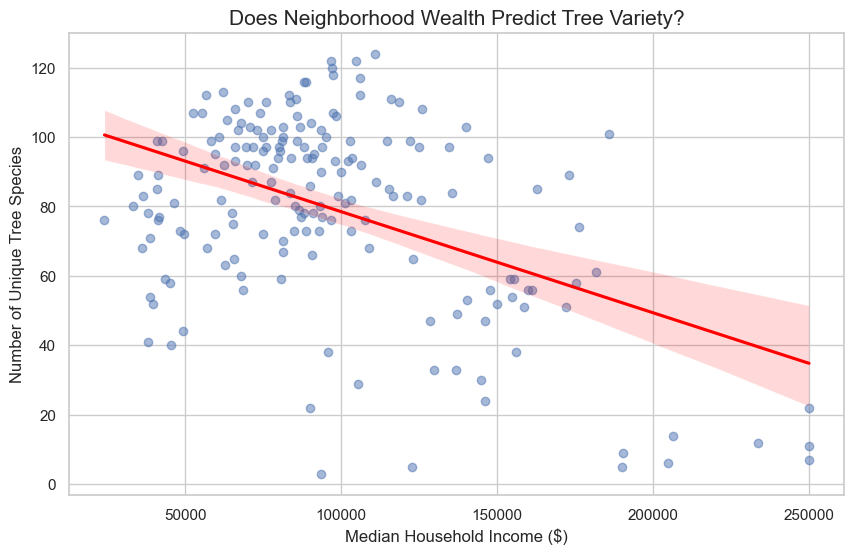

Overall City Correlation: -0.47


In [13]:
# ==========================================================
# ANALYSIS A: SPECIES DIVERSITY (RICHNESS)
# ==========================================================

# 1. Calculate how many unique species exist in each Zip Code
species_diversity = trees_df.groupby('postcode')['spc_common'].nunique().reset_index()
species_diversity.columns = ['zip_code', 'species_diversity']

# 2. Add this diversity score to our master table
final_df = final_df.merge(species_diversity, on='zip_code', how='left')

# 3. Visualization: Correlation between Income and Variety
plt.figure(figsize=(10, 6))
sns.regplot(data=final_df, x='median_income', y='species_diversity', 
            scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})

plt.title('Does Neighborhood Wealth Predict Tree Variety?', fontsize=15)
plt.xlabel('Median Household Income ($)')
plt.ylabel('Number of Unique Tree Species')
plt.show()

# 4. Statistical Result
corr = final_df['median_income'].corr(final_df['species_diversity'])
print(f"Overall City Correlation: {corr:.2f}")

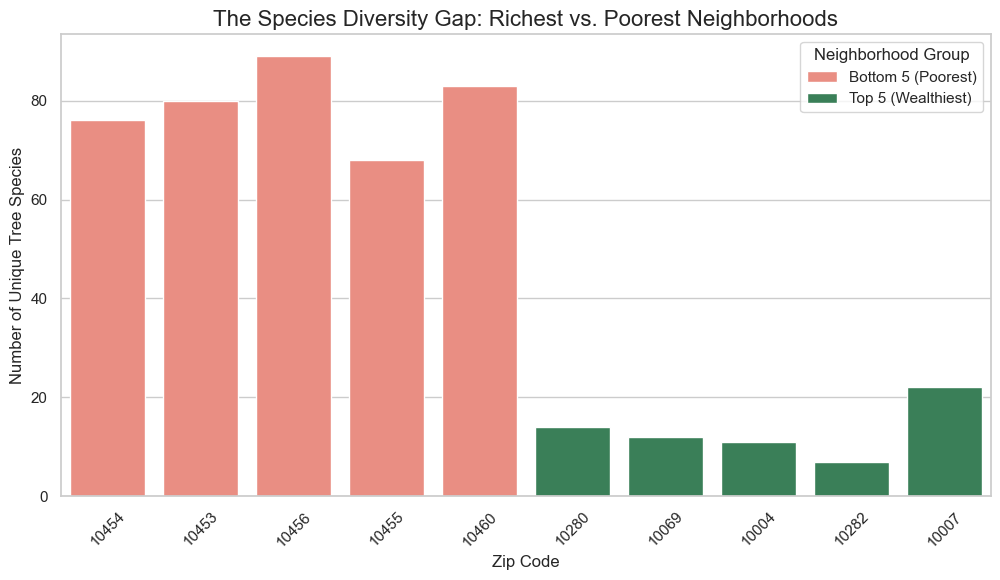

Average species in poorest 5 Zips: 79.2
Average species in wealthiest 5 Zips: 13.2
Outcome: Wealthy neighborhoods have -83.3% more tree variety than poor ones.


In [28]:
# ==========================================================
# ANALYSIS A.2: THE DIVERSITY WEALTH GAP
# ==========================================================

# 1. Identify the 5 Wealthiest and 5 Poorest Zip Codes
poorest_5 = final_df.nsmallest(5, 'median_income').copy()
wealthiest_5 = final_df.nlargest(5, 'median_income').copy()

# 2. Add a label so we can tell them apart in the chart
poorest_5['Group'] = 'Bottom 5 (Poorest)'
wealthiest_5['Group'] = 'Top 5 (Wealthiest)'

# 3. Combine them into one temporary table for plotting
comparison_df = pd.concat([poorest_5, wealthiest_5])

# 4. Visualization: Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(
    data=comparison_df.sort_values('median_income'), 
    x='zip_code', 
    y='species_diversity', 
    hue='Group',
    palette={'Bottom 5 (Poorest)': 'salmon', 'Top 5 (Wealthiest)': 'seagreen'}
)

plt.title('The Species Diversity Gap: Richest vs. Poorest Neighborhoods', fontsize=16)
plt.xlabel('Zip Code', fontsize=12)
plt.ylabel('Number of Unique Tree Species', fontsize=12)
plt.legend(title='Neighborhood Group')
plt.xticks(rotation=45)
plt.show()

# 5. Calculation: The "Variety Gap" Percentage
avg_poor = poorest_5['species_diversity'].mean()
avg_rich = wealthiest_5['species_diversity'].mean()
gap = ((avg_rich - avg_poor) / avg_poor) * 100

print(f"Average species in poorest 5 Zips: {avg_poor:.1f}")
print(f"Average species in wealthiest 5 Zips: {avg_rich:.1f}")
print(f"Outcome: Wealthy neighborhoods have {gap:.1f}% more tree variety than poor ones.")

In [14]:
# ==========================================================
# ANALYSIS B: DIVERSITY TRENDS BY BOROUGH
# ==========================================================

# 1. Filter out "Extreme" Zip Codes (those with way too many or too few trees)
# This prevents a massive park or a tiny industrial lot from skewing the results
mean_trees = final_df['tree_count'].mean()
std_trees = final_df['tree_count'].std()

close_avg_df = final_df[
    (final_df['tree_count'] >= mean_trees - std_trees) & 
    (final_df['tree_count'] <= mean_trees + std_trees)
].copy()

# 2. Calculate Correlation for each Borough individually
print("Correlation by Borough (Income vs. Species Variety):")
for borough in close_avg_df['borough'].dropna().unique():
    subset = close_avg_df[close_avg_df['borough'] == borough]
    if len(subset) > 5:
        borough_corr = subset['median_income'].corr(subset['species_diversity'])
        print(f" - {borough:15} | Correlation: {borough_corr:+.2f}")

Correlation by Borough (Income vs. Species Variety):
 - Manhattan       | Correlation: -0.37
 - Staten Island   | Correlation: -0.20
 - Bronx           | Correlation: +0.21
 - Queens          | Correlation: -0.22
 - Brooklyn        | Correlation: +0.16


C:\Users\Yoga_\AppData\Local\Temp\ipykernel_24776\1970044516.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=borough_top_15, x='avg_health_score', y='spc_common', palette='viridis')


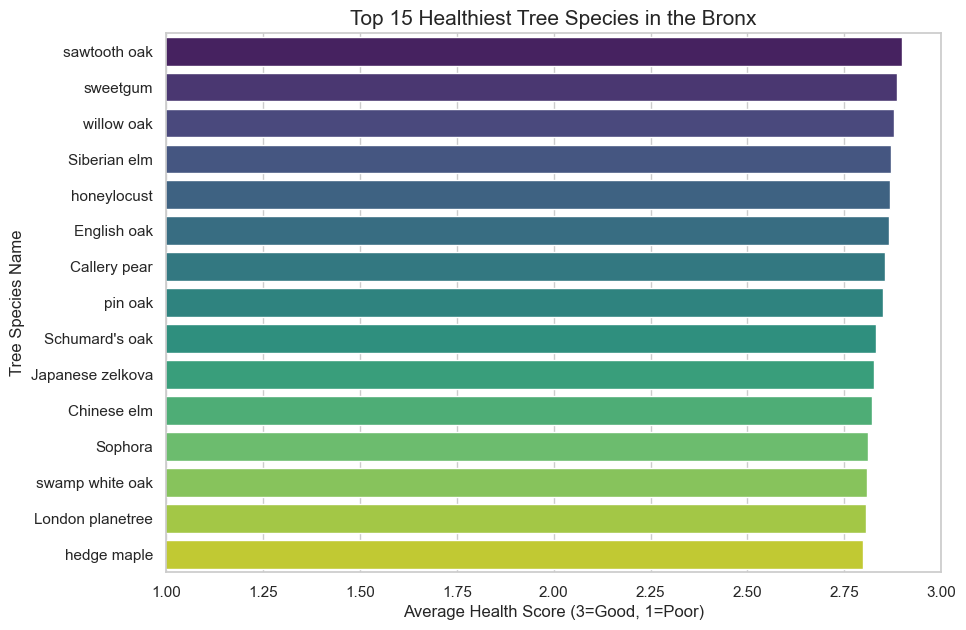

In [15]:
# ==========================================================
# ANALYSIS C: MOST RESILIENT SPECIES BY BOROUGH
# ==========================================================

# 1. Calculate health stats for every species in every borough
species_borough_health = trees_df.groupby(['borough', 'spc_common']).agg(
    tree_count=('tree_id', 'count'),
    avg_health_score=('health_numeric', 'mean')
).reset_index()

# 2. Filter: Only look at species with at least 200 trees (for statistical reliability)
species_borough_health = species_borough_health[species_borough_health['tree_count'] >= 200]

# 3. Visualization: Focus on the Bronx (per your project goal)
target_borough = 'Bronx'
borough_top_15 = species_borough_health[
    species_borough_health['borough'] == target_borough
].sort_values(by='avg_health_score', ascending=False).head(15)

plt.figure(figsize=(10, 7))
sns.barplot(data=borough_top_15, x='avg_health_score', y='spc_common', palette='viridis')
plt.title(f'Top 15 Healthiest Tree Species in the {target_borough}', fontsize=15)
plt.xlabel('Average Health Score (3=Good, 1=Poor)')
plt.ylabel('Tree Species Name')
plt.xlim(1, 3) # Set scale to match our 1-3 health scores
plt.show()

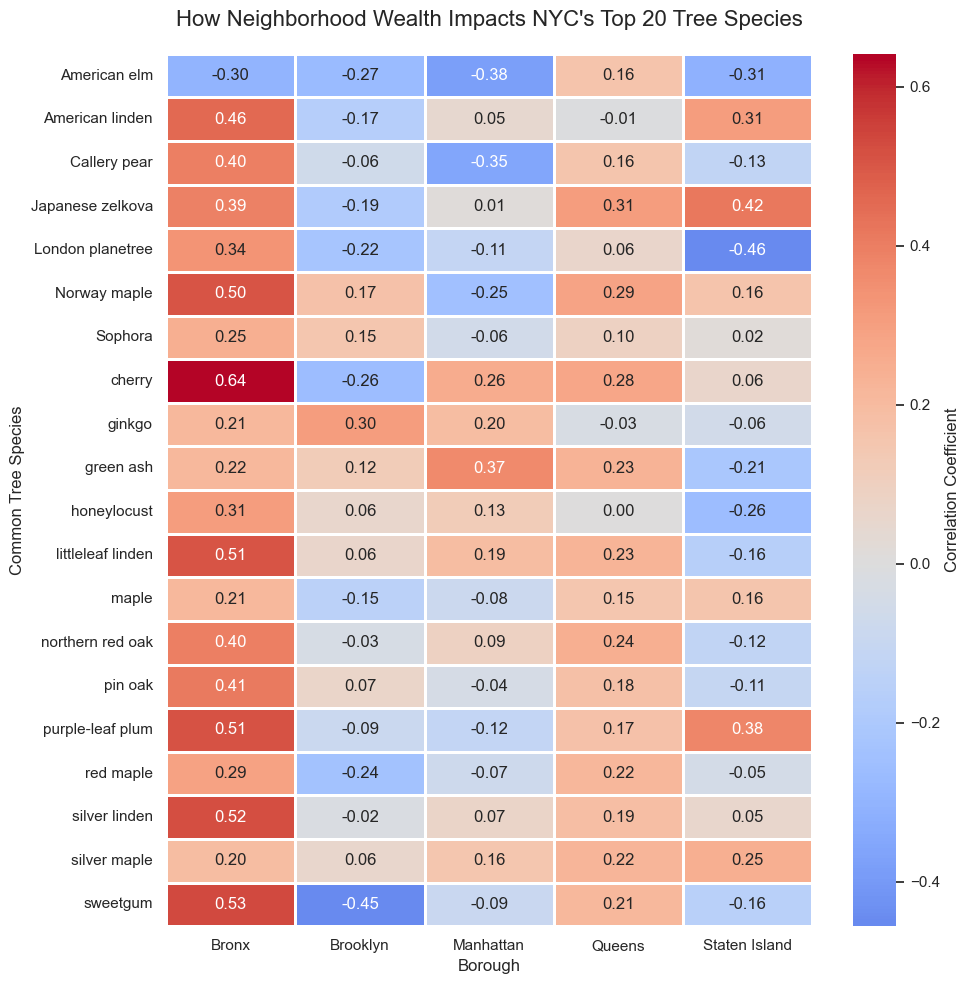

In [ ]:
# ==========================================================
# ANALYSIS D: THE "CLEAN" MASTER HEATMAP
# ==========================================================

# 1. Identify the Top 20 most common species city-wide to reduce clutter
top_20_species = trees_df['spc_common'].value_counts().head(20).index

# 2. Re-filter our correlation data to only include these top species
filtered_corr_df = corr_df[corr_df['species'].isin(top_20_species)]

# 3. Create the Pivot Table
heatmap_df = filtered_corr_df.pivot(index='species', columns='borough', values='correlation')

# 4. Visualization
plt.figure(figsize=(10, 10)) # Smaller, more square size is easier to read

sns.heatmap(
    heatmap_df, 
    cmap='coolwarm',     # Red = Positive correlation, Blue = Negative
    center=0, 
    annot=True,          # Put the actual numbers in the boxes
    fmt=".2f",           # Limit numbers to 2 decimal places
    linewidths=1, 
    cbar_kws={'label': 'Correlation Coefficient'}
)

plt.title('How Neighborhood Wealth Impacts NYC\'s Top 20 Tree Species', fontsize=16, pad=20)
plt.xlabel('Borough', fontsize=12)
plt.ylabel('Common Tree Species', fontsize=12)
plt.tight_layout() # Prevents label cutoff
plt.show()
# Closer to red means more correlation, so with these trees in this borough we see a strong correlation.
# Species that have a strong correlation are considered vulernable, meaning we should avoid planting these in low income areas. In low income areas, prefer trees in the white or blue color range.



In [27]:
# ==========================================================
# TOOL: PRINT CORRELATION NUMBERS AS TEXT
# ==========================================================

# 1. Identify the Top 20 most common species (same as the heatmap)
top_20_species = trees_df['spc_common'].value_counts().head(20).index

# 2. Filter the correlation data we calculated earlier
text_df = corr_df[corr_df['species'].isin(top_20_species)]

# 3. Pivot to match the heatmap layout
text_table = text_df.pivot(index='species', columns='borough', values='correlation')

# 4. Round to 3 decimal places for readability
text_table = text_table.round(3)

print("--- TREE CORRELATION DATA (SPECIES vs BOROUGH) ---")
print("Positive (+) = Health follows Wealth (Vulnerable)")
print("Near Zero (0) = Equity Resilient (Neutral)")
print("Negative (-) = High Resilience (Tough)")
print("-" * 60)
print(text_table.to_string())

--- TREE CORRELATION DATA (SPECIES vs BOROUGH) ---
Positive (+) = Health follows Wealth (Vulnerable)
Near Zero (0) = Equity Resilient (Neutral)
Negative (-) = High Resilience (Tough)
------------------------------------------------------------
borough            Bronx  Brooklyn  Manhattan  Queens  Staten Island
species                                                             
American elm      -0.302    -0.272     -0.379   0.163         -0.311
American linden    0.461    -0.167      0.048  -0.006          0.306
Callery pear       0.401    -0.065     -0.354   0.160         -0.126
Japanese zelkova   0.392    -0.188      0.014   0.309          0.416
London planetree   0.340    -0.223     -0.109   0.059         -0.456
Norway maple       0.504     0.171     -0.249   0.286          0.165
Sophora            0.249     0.149     -0.061   0.097          0.017
cherry             0.642    -0.262      0.258   0.276          0.065
ginkgo             0.215     0.303      0.196  -0.025         -0.0